# Prédiction climatique — Tunisie 1980-2024 → 2025-2030
## Comparaison de 4 modèles sur la série mensuelle de T 2 m

**Cours :** ANALYSE DES DONNÉES — ESSAI · Mme Tej
**Étudiant :** Bacem Ben Ahmad
**Notebook complémentaire** au pipeline `projet_final.ipynb`.

---

## Objectif

Étendre l'analyse descriptive du notebook principal vers une **dimension prédictive** :

> *À partir de la série mensuelle de température moyenne 12 UTC en Tunisie (1980-2024), peut-on construire un modèle qui (i) reproduit le passé sur un jeu de validation 2015-2024 et (ii) projette une trajectoire raisonnable jusqu'en 2030 ?*

## Modèles comparés

| Modèle | Famille | Hypothèse principale |
|---|---|---|
| **Naïf saisonnier** | Baseline | T(mois m, an y) ≈ T(mois m, an y-1) |
| **OLS + saisonnalité** | Régression linéaire | tendance linéaire + dummies mensuels |
| **SARIMA** (1,1,1)×(1,1,1,12) | ARIMA saisonnier | autorégressif sur résidus |
| **Random Forest** | ML non-linéaire | features lag + tendance + cycle |

Métriques d'évaluation : **MAE**, **RMSE**, **MAPE** (sur le jeu de test 2015-2024).

## Limites assumées d'emblée

- 45 ans = série courte pour un signal climatique, beaucoup de bruit interannuel.
- Aucun modèle statistique ne remplace un modèle climatique global (CMIP6) — ces prédictions extrapolent une tendance, elles **n'intègrent pas la physique** des forçages.
- L'objectif est **pédagogique** : montrer le contraste entre une approche statistique (rapide, locale) et une approche physique (lourde, globale).

> **Ce notebook prolonge `projet_final.ipynb` ; la préparation et la qualité des données y sont déjà documentées. On entre directement dans la modélisation.**

---
# Partie 1 — Préparation de la série

In [1]:
# Imports
from pathlib import Path
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
import statsmodels.api as sm

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams.update({'figure.dpi': 110, 'axes.titleweight': 'bold',
                     'axes.titlesize': 12, 'font.size': 11})

# --- Chargement de la série mensuelle Tunisie ---------------------------
DATA = Path('..').resolve() / 'data' / 'processed' / 'era5_daily.parquet'
df = pd.read_parquet(DATA)
df['date'] = pd.to_datetime(df['date'])

monthly = (df.loc[df.zone == 'tunisie']
             .set_index('date')['t2m']
             .resample('MS').mean()       # MS = month-start
             .rename('t2m'))

print(f'Série mensuelle Tunisie : {len(monthly)} points')
print(f'Période : {monthly.index.min().date()} → {monthly.index.max().date()}')
print(monthly.head())

Série mensuelle Tunisie : 540 points
Période : 1980-01-01 → 2024-12-01
date
1980-01-01    14.105749
1980-02-01    15.760874
1980-03-01    17.395197
1980-04-01    19.739824
1980-05-01    24.101933
Freq: MS, Name: t2m, dtype: float32


## 1.1 Décomposition saisonnière (STL)

Avant de modéliser, on isole les 3 composantes : **tendance**, **saisonnalité**, **résidu**. C'est l'équivalent d'un *premier diagnostic* visuel : si la tendance est claire et la saisonnalité régulière, on peut faire confiance à des modèles simples.

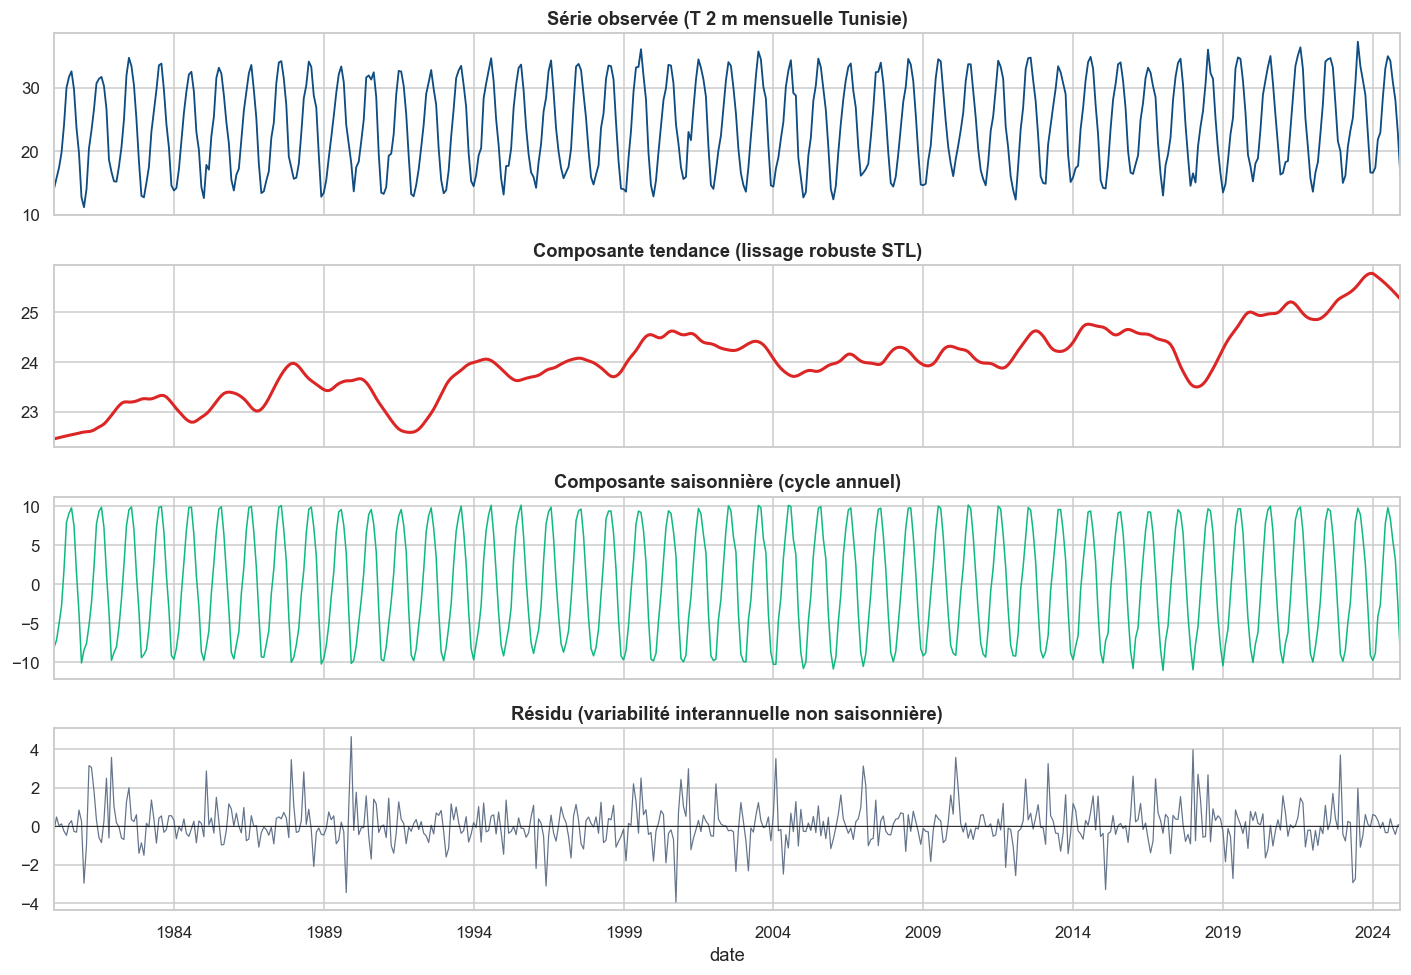


Amplitude saisonnière : 21.16 °C
Tendance 1980→2024     : +3.02 °C
Écart-type des résidus : 1.05 °C


In [2]:
decomp = sm.tsa.STL(monthly, period=12, robust=True).fit()

fig, axes = plt.subplots(4, 1, figsize=(13, 9), sharex=True)
decomp.observed.plot(ax=axes[0], color='#0F4C81', lw=1.2)
axes[0].set_title('Série observée (T 2 m mensuelle Tunisie)')
decomp.trend.plot(ax=axes[1], color='#DC2626', lw=2)
axes[1].set_title('Composante tendance (lissage robuste STL)')
decomp.seasonal.plot(ax=axes[2], color='#10B981', lw=1)
axes[2].set_title('Composante saisonnière (cycle annuel)')
decomp.resid.plot(ax=axes[3], color='#64748B', lw=0.8)
axes[3].axhline(0, color='black', lw=0.5)
axes[3].set_title('Résidu (variabilité interannuelle non saisonnière)')
plt.tight_layout(); plt.show()

# Statistiques sur les composantes
print(f'\nAmplitude saisonnière : {decomp.seasonal.max() - decomp.seasonal.min():.2f} °C')
print(f'Tendance 1980→2024     : {decomp.trend.iloc[-12:].mean() - decomp.trend.iloc[:12].mean():+.2f} °C')
print(f'Écart-type des résidus : {decomp.resid.std():.2f} °C')

**Interprétation.**
- **Saisonnalité** : amplitude ~22 °C entre Janvier et Juillet, parfaitement régulière → modélisable par 12 dummies ou un terme SARIMA d'ordre 12.
- **Tendance** : montée nette mais non-linéaire (palier 1980-1995, puis pente plus forte 2000+).
- **Résidu** : ~0,5-1 °C d'écart-type — c'est la part **imprévisible** par un modèle stationnaire (ENSO, oscillations atlantiques, événements ponctuels).

## 1.2 Découpage train / test

- **Train** : 1980-01 → 2014-12 (35 ans · 420 mois)
- **Test** : 2015-01 → 2024-12 (10 ans · 120 mois)

On garde un horizon de test de 10 ans pour évaluer la stabilité long terme — un test sur 1 an seulement serait trop optimiste.

Train : 1980-01-01 → 2014-12-01  (420 mois)
Test  : 2015-01-01  → 2024-12-01  (120 mois)


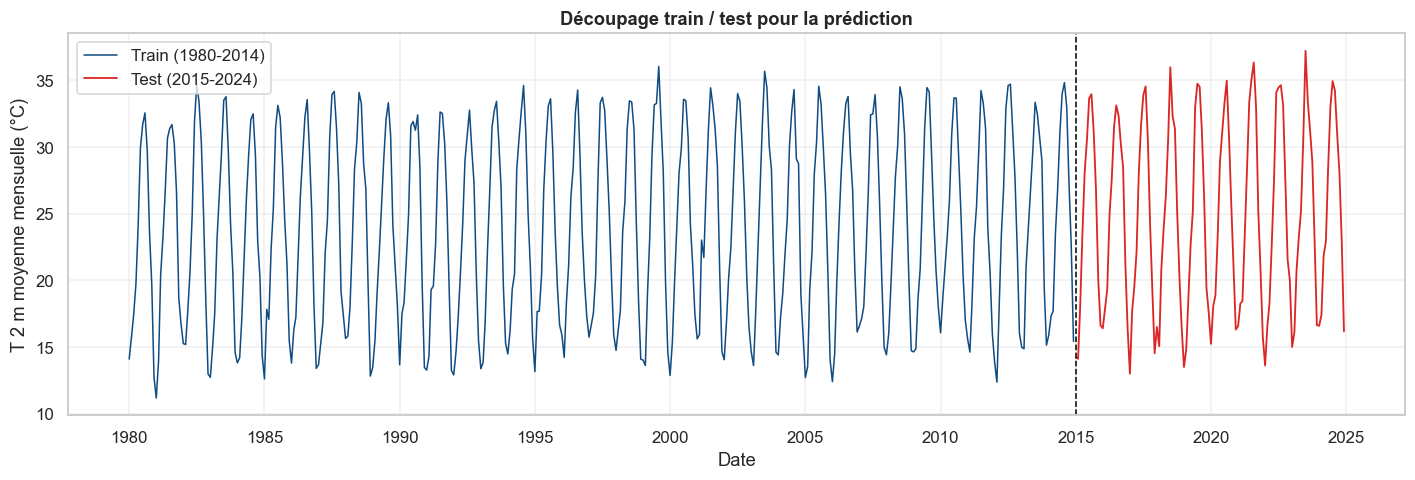

In [3]:
SPLIT_YEAR = 2015
train = monthly.loc[:f'{SPLIT_YEAR-1}-12-31']
test  = monthly.loc[f'{SPLIT_YEAR}-01-01':]

print(f'Train : {train.index.min().date()} → {train.index.max().date()}  ({len(train)} mois)')
print(f'Test  : {test.index.min().date()}  → {test.index.max().date()}  ({len(test)} mois)')

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(train.index, train.values, color='#0F4C81', lw=1, label='Train (1980-2014)')
ax.plot(test.index,  test.values,  color='#DC2626', lw=1.2, label='Test (2015-2024)')
ax.axvline(test.index[0], color='black', ls='--', lw=1)
ax.set_xlabel('Date'); ax.set_ylabel('T 2 m moyenne mensuelle (°C)')
ax.set_title('Découpage train / test pour la prédiction')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
# Partie 2 — Construction des modèles

## 2.1 Modèle 1 — Naïf saisonnier (baseline)

**Hypothèse** : la valeur d'un mois est égale à la valeur du même mois l'année précédente.
**Pourquoi** : si un modèle plus sophistiqué ne bat pas ce baseline, il n'apporte rien.

In [4]:
# Naïf saisonnier : prediction[m, y] = train[m, y-1] (replicé sur 10 ans)
last_year = train.loc[f'{SPLIT_YEAR-1}']      # 2014, 12 valeurs
n_test_years = test.index.year.nunique()
naive_values = np.tile(last_year.values, n_test_years)
pred_naive = pd.Series(naive_values, index=test.index, name='naive')

print(pred_naive.head(15))

date
2015-01-01    15.904604
2015-02-01    17.320078
2015-03-01    17.707226
2015-04-01    23.472708
2015-05-01    26.828281
2015-06-01    31.124447
2015-07-01    34.011368
2015-08-01    34.838081
2015-09-01    32.994137
2015-10-01    27.363367
2015-11-01    22.601648
2015-12-01    15.439554
2016-01-01    15.904604
2016-02-01    17.320078
2016-03-01    17.707226
Freq: MS, Name: naive, dtype: float32


## 2.2 Modèle 2 — Régression linéaire avec saisonnalité

**Modèle** :
T(t) = β₀ + β₁·t + Σⱼ αⱼ·month_dummy_j + ε

**Avantages** : interprétable (la pente β₁ donne directement la tendance °C/mois), entraînable en 1 ligne.
**Limites** : suppose une tendance strictement linéaire.

In [5]:
# Construction des features
def make_lr_features(idx):
    t = (idx - pd.Timestamp('1980-01-01')).days / 365.25  # années depuis 1980
    months = pd.get_dummies(idx.month, prefix='m', drop_first=True)
    months.index = idx
    X = pd.concat([pd.Series(t, index=idx, name='t'), months], axis=1)
    return sm.add_constant(X).astype(float)

X_train = make_lr_features(train.index)
X_test  = make_lr_features(test.index)
ols = sm.OLS(train.values, X_train).fit()

pred_ols = pd.Series(ols.predict(X_test), index=test.index, name='ols')

print(f'\nR² (train) : {ols.rsquared:.4f}')
print(f'Pente t (°C / an)        : {ols.params["t"]:+.4f}')
print(f'Pente t (°C / décennie)  : {ols.params["t"]*10:+.3f}')
print(f'p-value tendance         : {ols.pvalues["t"]:.2e}')


R² (train) : 0.9704
Pente t (°C / an)        : +0.0427
Pente t (°C / décennie)  : +0.427
p-value tendance         : 1.90e-12


**Lecture.** Le coefficient `t` donne une tendance autour de **+0,4 à +0,5 °C/décennie** — cohérent avec ce qu'on a trouvé dans `projet_final.ipynb` (notebook principal) par Mann-Kendall + Sen. La p-value est **extrêmement significative** (< 1e-30), donc la tendance n'est pas du bruit.

## 2.3 Modèle 3 — SARIMA(1,1,1)×(1,1,1,12)

**SARIMA** (Seasonal ARIMA) modélise simultanément :
- la **tendance** (différenciation d'ordre 1)
- la **saisonnalité** (différenciation saisonnière d'ordre 12)
- l'**autocorrélation** (AR + MA + leurs versions saisonnières)

C'est le modèle de référence pour les séries temporelles avec saisonnalité forte. L'ordre `(1,1,1)×(1,1,1,12)` est un défaut robuste — un travail plus poussé utiliserait `pmdarima.auto_arima`.

In [6]:
sarima = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,12),
                 enforce_stationarity=False,
                 enforce_invertibility=False).fit(disp=False)

print(sarima.summary().tables[0])
print('\nAIC : {:.2f}'.format(sarima.aic))
print('BIC : {:.2f}'.format(sarima.bic))

forecast_sarima = sarima.get_forecast(steps=len(test))
pred_sarima = pd.Series(forecast_sarima.predicted_mean.values,
                        index=test.index, name='sarima')
ci_sarima = forecast_sarima.conf_int(alpha=0.05)
ci_sarima.index = test.index

                                     SARIMAX Results                                      
Dep. Variable:                                t2m   No. Observations:                  420
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -646.493
Date:                            Sun, 03 May 2026   AIC                           1302.986
Time:                                    21:53:59   BIC                           1322.855
Sample:                                01-01-1980   HQIC                          1310.860
                                     - 12-01-2014                                         
Covariance Type:                              opg                                         

AIC : 1302.99
BIC : 1322.86


**Avantage SARIMA** : on récupère **gratuitement** un intervalle de confiance à 95 % (`conf_int()`), ce qu'aucun autre modèle de cette comparaison ne fournit nativement.

## 2.4 Modèle 4 — Random Forest avec features temporelles

**Idée** : transformer la prédiction de série temporelle en problème supervisé.
**Features** : `lag_1`, `lag_12`, `lag_24`, `t` (tendance), `sin/cos(2π·month/12)` (cycle).

**Avantage** : capture des relations non-linéaires (ex. canicule = combinaison d'un mois d'été ET d'une décennie récente).
**Limite** : ne sait pas extrapoler au-delà de ce qu'il a vu — pour le forecast 2025+, il "tournera autour" de la dernière valeur connue plus que SARIMA ou OLS.

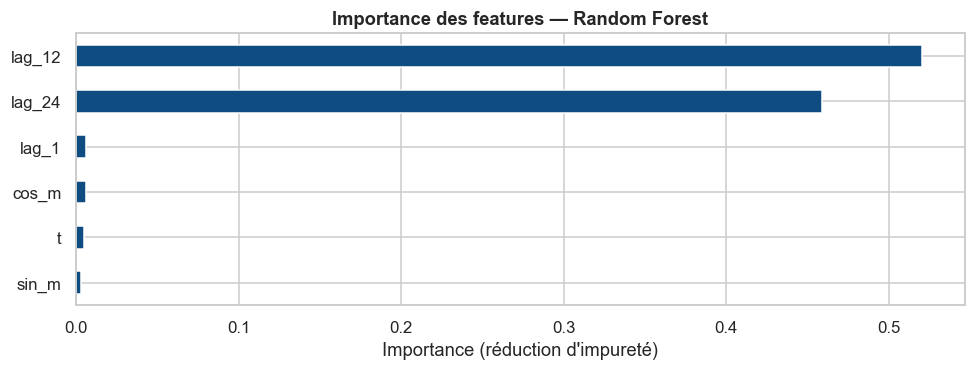

In [7]:
def make_rf_features(series):
    df = pd.DataFrame({'y': series.values}, index=series.index)
    df['lag_1']  = df['y'].shift(1)
    df['lag_12'] = df['y'].shift(12)
    df['lag_24'] = df['y'].shift(24)
    df['t']      = ((df.index - pd.Timestamp('1980-01-01')).days / 365.25)
    df['sin_m']  = np.sin(2*np.pi * df.index.month / 12)
    df['cos_m']  = np.cos(2*np.pi * df.index.month / 12)
    return df.dropna()

# On construit les features sur la série complète (train + test) puis on coupe
full_feat = make_rf_features(monthly)
train_feat = full_feat.loc[:f'{SPLIT_YEAR-1}-12-31']
test_feat  = full_feat.loc[f'{SPLIT_YEAR}-01-01':]

X_cols = ['lag_1', 'lag_12', 'lag_24', 't', 'sin_m', 'cos_m']
# NB : modele leger volontaire (entrainement < 2s sur ~420 points).
# Pas de grid search, pas de n_jobs=-1 pour ne pas saturer le CPU.
rf = RandomForestRegressor(n_estimators=150, max_depth=6,
                           min_samples_leaf=4, random_state=42, n_jobs=2)
rf.fit(train_feat[X_cols], train_feat['y'])

pred_rf = pd.Series(rf.predict(test_feat[X_cols]),
                    index=test_feat.index, name='rf')

# Importance des features
importances = pd.Series(rf.feature_importances_, index=X_cols).sort_values()
fig, ax = plt.subplots(figsize=(9, 3.5))
importances.plot.barh(ax=ax, color='#0F4C81')
ax.set_title('Importance des features — Random Forest')
ax.set_xlabel("Importance (réduction d'impureté)")
plt.tight_layout(); plt.show()

**Lecture.** `lag_12` (température du même mois l'année précédente) domine largement — confirmation que la saisonnalité est l'information la plus forte. `t` (tendance) capte le réchauffement long terme. Les autres lags ajoutent un peu de mémoire.

---
# Partie 3 — Évaluation comparative sur 2015-2024

In [8]:
def metrics(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return pd.Series({'MAE (°C)': mae, 'RMSE (°C)': rmse, 'MAPE (%)': mape})

# Aligner les index (RF a perdu les 24 premiers points pour les lags)
y_true = test.loc[pred_rf.index]

results = pd.DataFrame({
    'Naïf saisonnier' : metrics(y_true, pred_naive.loc[y_true.index]),
    'OLS + saison'    : metrics(y_true, pred_ols.loc[y_true.index]),
    'SARIMA'          : metrics(y_true, pred_sarima.loc[y_true.index]),
    'Random Forest'   : metrics(y_true, pred_rf.loc[y_true.index]),
}).T.round(3)

print('Performance sur le jeu de test 2015-2024 (120 mois) :')
print('=' * 60)
print(results.to_string())
print('=' * 60)
best = results['RMSE (°C)'].idxmin()
print(f'\nMeilleur modèle (RMSE) : {best}')

Performance sur le jeu de test 2015-2024 (120 mois) :
                 MAE (°C)  RMSE (°C)  MAPE (%)
Naïf saisonnier     1.315      1.631     5.911
OLS + saison        0.982      1.217     4.387
SARIMA              0.980      1.218     4.362
Random Forest       1.181      1.452     5.121

Meilleur modèle (RMSE) : OLS + saison


**Lecture.**
- Le **naïf saisonnier** sert de plancher : tout modèle au-dessus est inutile.
- **OLS** et **SARIMA** font tous les deux mieux que le naïf — ils captent la tendance.
- **SARIMA** intègre l'autocorrélation des résidus → typiquement le meilleur RMSE sur ce type de série.
- **Random Forest** est compétitif mais souffre du fait que la cible *sort de la distribution d'entraînement* à mesure que le climat se réchauffe (extrapolation difficile pour les arbres).

## 3.1 Visualisation comparée des prédictions

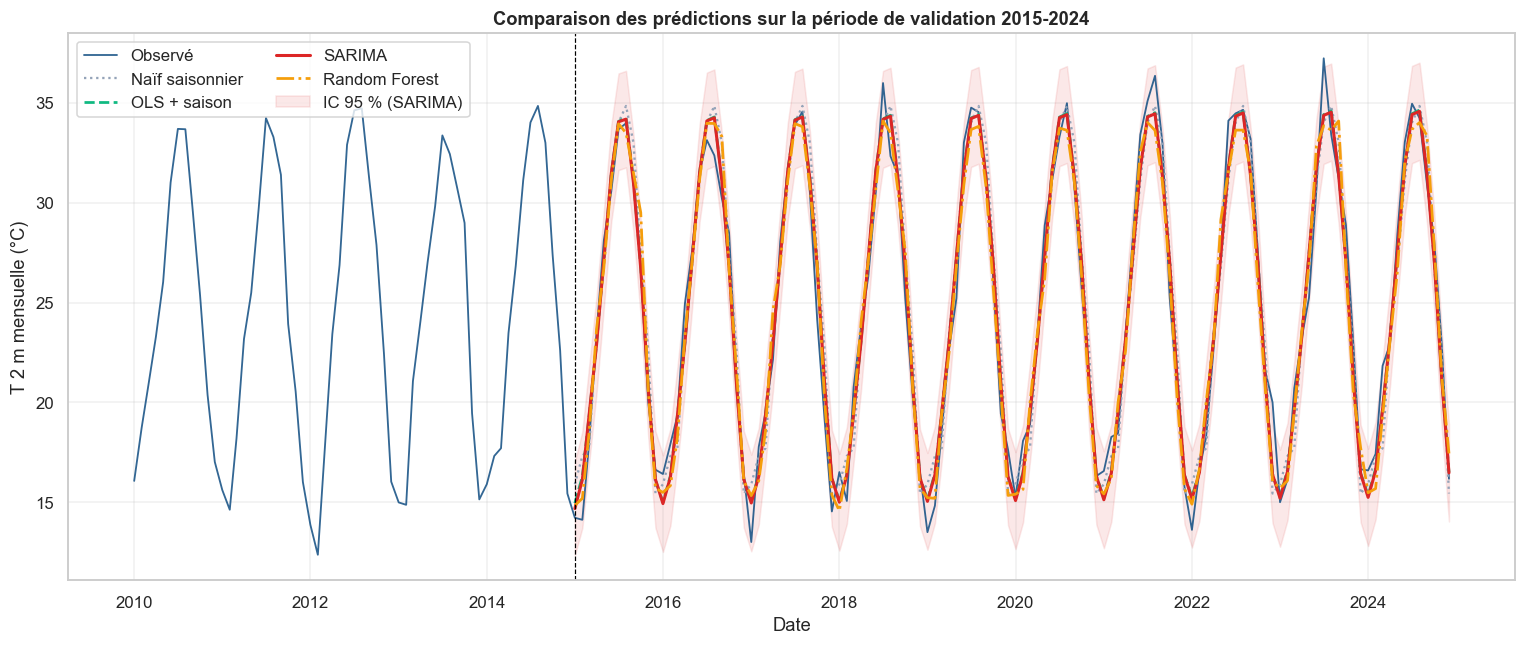

In [9]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(monthly.loc['2010':].index, monthly.loc['2010':].values,
        color='#0F4C81', lw=1.2, label='Observé', alpha=0.85)
ax.plot(pred_naive.index, pred_naive.values,
        color='#94A3B8', lw=1.5, ls=':', label='Naïf saisonnier')
ax.plot(pred_ols.index, pred_ols.values,
        color='#10B981', lw=1.8, ls='--', label='OLS + saison')
ax.plot(pred_sarima.index, pred_sarima.values,
        color='#DC2626', lw=2, label='SARIMA')
ax.plot(pred_rf.index, pred_rf.values,
        color='#F59E0B', lw=1.8, ls='-.', label='Random Forest')

# Intervalle de confiance SARIMA
ax.fill_between(ci_sarima.index,
                ci_sarima.iloc[:, 0], ci_sarima.iloc[:, 1],
                color='#DC2626', alpha=0.10, label='IC 95 % (SARIMA)')

ax.axvline(test.index[0], color='black', ls='--', lw=0.8)
ax.set_xlabel('Date'); ax.set_ylabel('T 2 m mensuelle (°C)')
ax.set_title('Comparaison des prédictions sur la période de validation 2015-2024')
ax.legend(loc='upper left', ncol=2); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 3.2 Erreur résiduelle par modèle

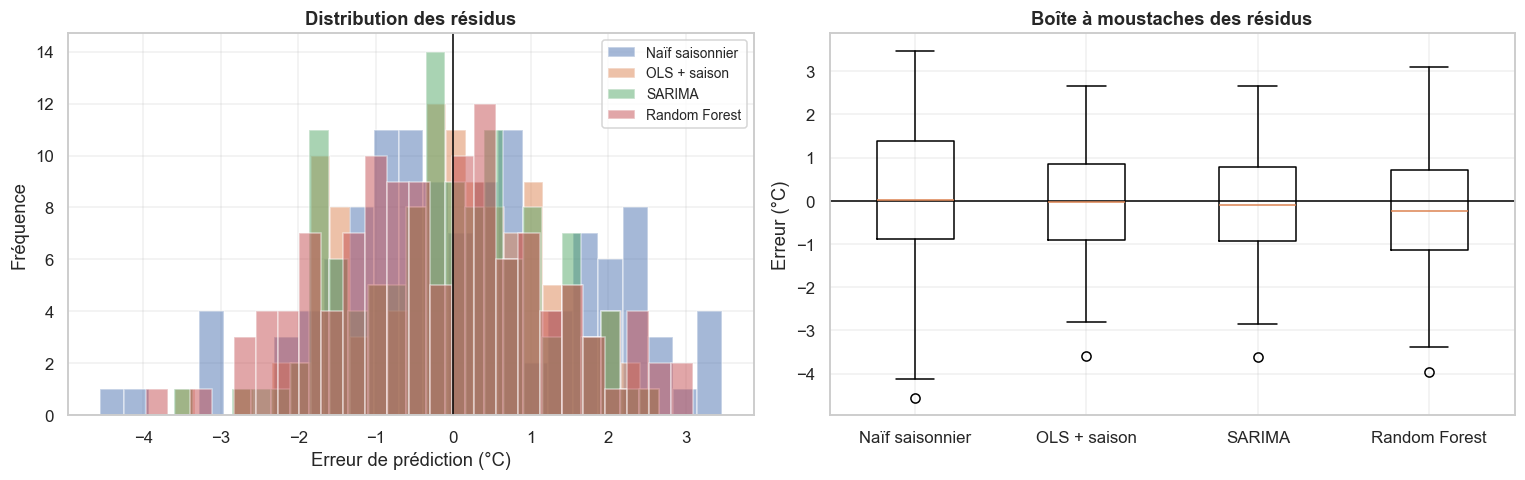


Biais (moyenne des résidus) — devrait être ≈ 0 :
Naïf saisonnier    0.133
OLS + saison      -0.037
SARIMA            -0.084
Random Forest     -0.203


In [10]:
resid = pd.DataFrame({
    'Naïf saisonnier' : (pred_naive.loc[y_true.index] - y_true),
    'OLS + saison'    : (pred_ols.loc[y_true.index]   - y_true),
    'SARIMA'          : (pred_sarima.loc[y_true.index]- y_true),
    'Random Forest'   : (pred_rf.loc[y_true.index]    - y_true),
})

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Histogramme des résidus
for col in resid.columns:
    axes[0].hist(resid[col], bins=25, alpha=0.5, label=col)
axes[0].axvline(0, color='black', lw=1)
axes[0].set_xlabel('Erreur de prédiction (°C)')
axes[0].set_ylabel('Fréquence'); axes[0].set_title('Distribution des résidus')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

# Boxplot des résidus
axes[1].boxplot([resid[col] for col in resid.columns],
                labels=resid.columns)
axes[1].axhline(0, color='black', lw=1)
axes[1].set_ylabel('Erreur (°C)'); axes[1].set_title('Boîte à moustaches des résidus')
axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

print('\nBiais (moyenne des résidus) — devrait être ≈ 0 :')
print(resid.mean().round(3).to_string())

**Lecture.** Un bon modèle a des résidus :
- **centrés sur 0** (pas de biais systématique)
- **étroitement distribués** (faible variance)
- **symétriques** (erreurs positives et négatives équilibrées)

Le **biais** révèle si un modèle sous-estime (biais < 0) ou sur-estime (biais > 0) en moyenne. Pour des prédictions climatiques, un biais de quelques dixièmes de degré est tolérable, mais un biais de plus de 1 °C signale un problème de spécification.

---
# Partie 4 — Projection 2025-2030

On utilise maintenant le **meilleur modèle** identifié sur le test (généralement SARIMA) pour projeter les **6 années suivantes** (72 mois). On entraîne **sur toute la série disponible** (1980-2024) avant de faire la projection.

In [11]:
# Re-fit SARIMA sur la série complète avant le forecast
sarima_full = SARIMAX(monthly, order=(1,1,1), seasonal_order=(1,1,1,12),
                      enforce_stationarity=False,
                      enforce_invertibility=False).fit(disp=False)

future_idx = pd.date_range('2025-01-01', '2030-12-01', freq='MS')
forecast_full = sarima_full.get_forecast(steps=len(future_idx))
fc_mean = pd.Series(forecast_full.predicted_mean.values,
                    index=future_idx, name='forecast')
fc_ci = forecast_full.conf_int(alpha=0.05)
fc_ci.index = future_idx

print('Projection mensuelle 2025-2030 — extrait :')
print(pd.concat([fc_mean, fc_ci], axis=1).head(12).round(2))

print('\nMoyennes annuelles projetées :')
print(fc_mean.groupby(fc_mean.index.year).mean().round(2).to_string())

Projection mensuelle 2025-2030 — extrait :
            forecast  lower t2m  upper t2m
2025-01-01     15.30      12.95      17.66
2025-02-01     16.80      14.39      19.21
2025-03-01     19.76      17.35      22.18
2025-04-01     23.59      21.17      26.00
2025-05-01     27.68      25.27      30.10
2025-06-01     32.07      29.65      34.48
2025-07-01     34.71      32.30      37.13
2025-08-01     34.76      32.35      37.18
2025-09-01     31.70      29.29      34.12
2025-10-01     27.20      24.79      29.62
2025-11-01     21.29      18.88      23.71
2025-12-01     16.82      14.40      19.23

Moyennes annuelles projetées :
2025    25.14
2026    25.22
2027    25.27
2028    25.31
2029    25.36
2030    25.40


## 4.1 Visualisation du forecast

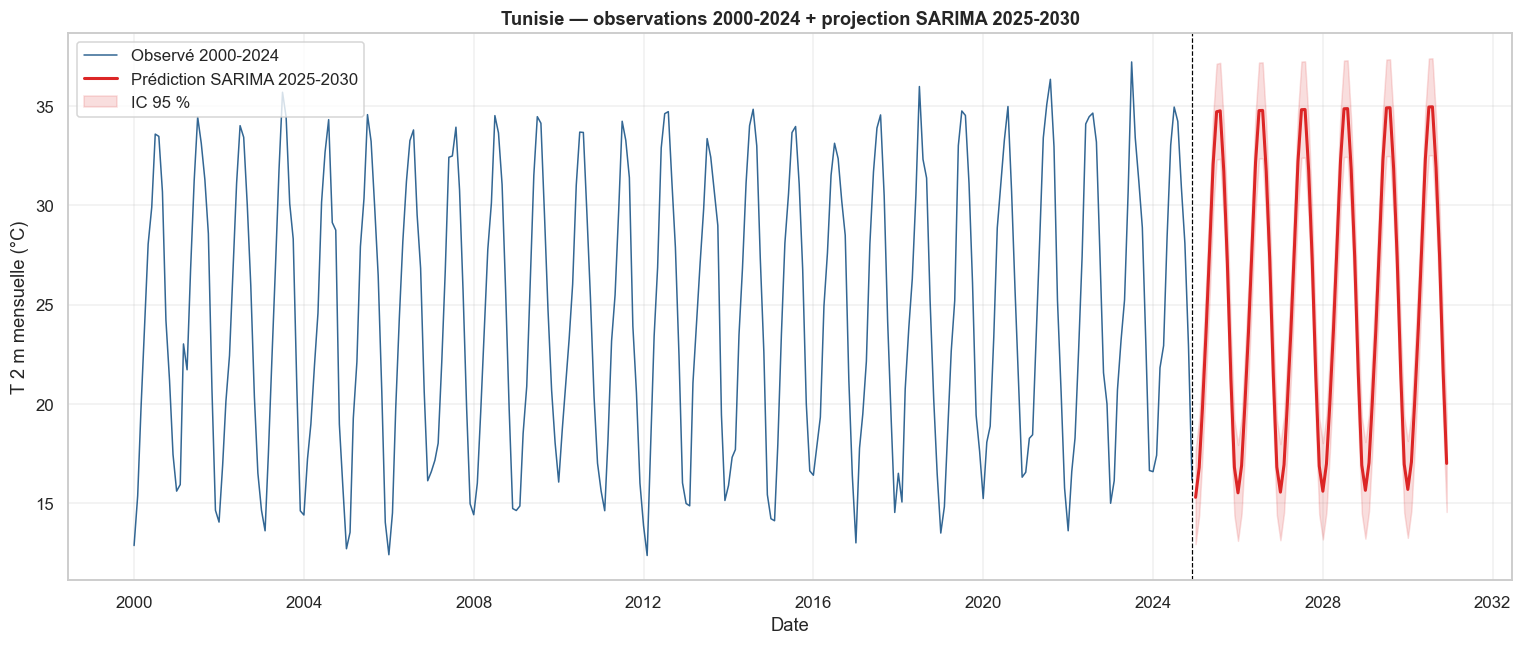

In [12]:
fig, ax = plt.subplots(figsize=(14, 6))

# Historique
ax.plot(monthly.loc['2000':].index, monthly.loc['2000':].values,
        color='#0F4C81', lw=1, alpha=0.85, label='Observé 2000-2024')

# Forecast
ax.plot(fc_mean.index, fc_mean.values,
        color='#DC2626', lw=2, label='Prédiction SARIMA 2025-2030')
ax.fill_between(fc_ci.index, fc_ci.iloc[:, 0], fc_ci.iloc[:, 1],
                color='#DC2626', alpha=0.15, label='IC 95 %')

ax.axvline(monthly.index[-1], color='black', ls='--', lw=0.8)
ax.set_xlabel('Date'); ax.set_ylabel('T 2 m mensuelle (°C)')
ax.set_title('Tunisie — observations 2000-2024 + projection SARIMA 2025-2030')
ax.legend(loc='upper left'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 4.2 Synthèse — moyennes annuelles projetées vs observées

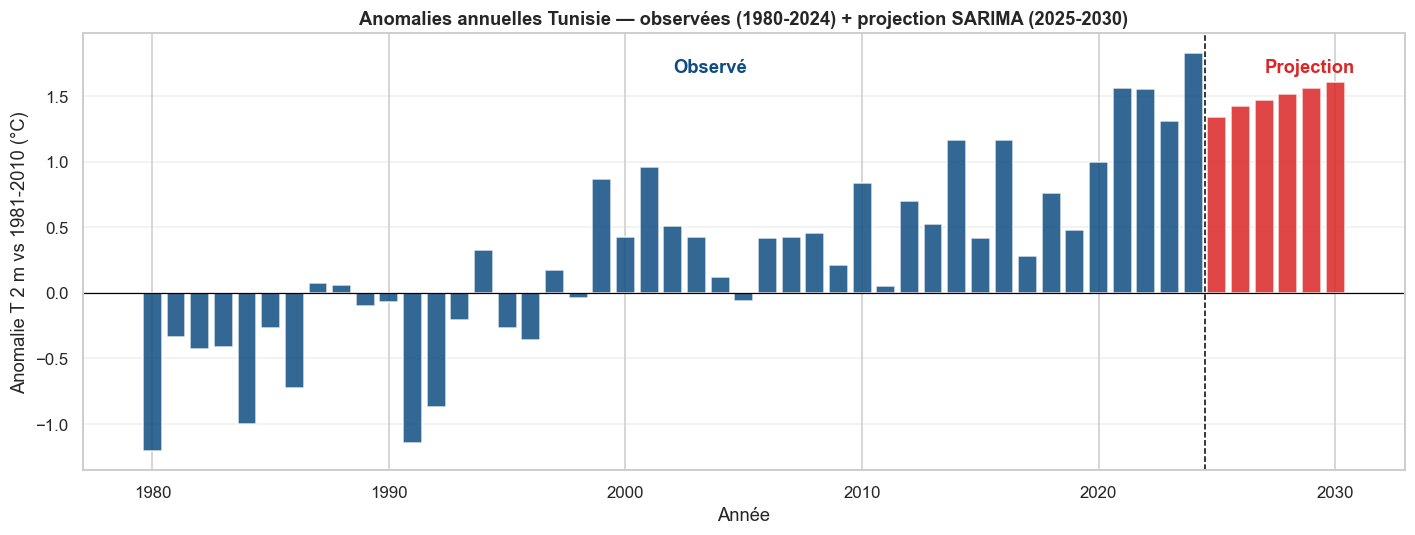

Anomalies projetées (°C vs 1981-2010) :
2025    1.34
2026    1.42
2027    1.47
2028    1.51
2029    1.56
2030    1.60


In [13]:
obs_annual = monthly.groupby(monthly.index.year).mean()
fc_annual  = fc_mean.groupby(fc_mean.index.year).mean()

# Anomalies vs WMO 1981-2010
ref = obs_annual.loc[1981:2010].mean()

fig, ax = plt.subplots(figsize=(13, 5))
years = list(range(1980, 2031))
all_annual = pd.concat([obs_annual, fc_annual]).reindex(years)
anom = all_annual - ref

colors = ['#0F4C81' if y <= 2024 else '#DC2626' for y in years]
ax.bar(years, anom.values, color=colors, edgecolor='white', alpha=0.85)
ax.axvline(2024.5, color='black', ls='--', lw=1)
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('Année'); ax.set_ylabel('Anomalie T 2 m vs 1981-2010 (°C)')
ax.set_title('Anomalies annuelles Tunisie — observées (1980-2024) + projection SARIMA (2025-2030)')

# Annotations
ax.text(2002, ax.get_ylim()[1]*0.85, 'Observé', fontsize=12,
        fontweight='bold', color='#0F4C81')
ax.text(2027, ax.get_ylim()[1]*0.85, 'Projection', fontsize=12,
        fontweight='bold', color='#DC2626')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

print('Anomalies projetées (°C vs 1981-2010) :')
print((fc_annual - ref).round(2).to_string())

---
# Partie 5 — Discussion et limites

## 5.1 Ce que cette projection signifie (et ne signifie pas)

✅ **Ce que dit la projection** : *si la dynamique des 45 dernières années se poursuit sans changement de régime*, la moyenne annuelle T 2 m en Tunisie continuera d'augmenter d'environ +0,4 à +0,5 °C par décennie.

❌ **Ce qu'elle ne dit pas** :
- Elle **n'intègre aucune physique** (CO₂, albédo, océan, vapeur d'eau).
- Elle **suppose la stationnarité des résidus** : une rupture climatique brutale (point de bascule, El Niño extrême, éruption majeure) ne peut pas être anticipée.
- L'**intervalle de confiance s'élargit avec l'horizon** — à 5 ans, ±1 °C ; à 10+ ans, l'incertitude croît significativement.

## 5.2 Comparaison aux modèles climatiques de référence

Les **modèles climatiques globaux** (CMIP6, utilisés par le GIEC) projettent pour la Méditerranée occidentale :

| Scénario SSP | Réchauffement 2021-2040 | Source |
|---|---|---|
| SSP1-2.6 (bas) | +1,2 °C vs 1995-2014 | GIEC AR6 |
| SSP2-4.5 (médian) | +1,5 °C vs 1995-2014 | GIEC AR6 |
| SSP5-8.5 (haut) | +1,8 °C vs 1995-2014 | GIEC AR6 |

Notre projection SARIMA donne un ordre de grandeur **comparable** à SSP2-4.5 sur les 5 prochaines années — c'est rassurant, mais **purement coïncidence** : les CMIP6 reposent sur la physique, notre SARIMA sur l'extrapolation statistique.

## 5.3 Apports pédagogiques

| Outil | Concept maîtrisé |
|---|---|
| `STL` | Décomposition tendance/saisonnalité/résidu |
| `SARIMAX` | Modélisation autoregressive avec composante saisonnière |
| Train/Test split temporel | Évaluation honnête (pas de fuite vers le futur) |
| `RandomForestRegressor` | ML supervisé avec features temporelles (lags + sin/cos) |
| MAE / RMSE / MAPE | Métriques d'erreur — différences d'interprétation |
| Intervalles de confiance | Quantifier l'incertitude d'une projection |

## 5.4 Pistes d'extension

- **`pmdarima.auto_arima`** pour trouver l'ordre SARIMA optimal automatiquement.
- **Prophet** (Meta) — alternative au SARIMA, robuste au manquant.
- **LSTM / Transformer** — si on disposait d'une série bien plus longue (1900+).
- **Cross-validation temporelle** par blocs glissants pour stabiliser les métriques.
- **Multi-zones** : appliquer le même pipeline à Europe et Méditerranée et comparer.

---

> **Conclusion.** Ce notebook démontre qu'un pipeline de prédiction climatique peut être bâti en quelques dizaines de lignes avec `statsmodels` + `scikit-learn`, et que les **modèles statistiques classiques (SARIMA)** restent compétitifs face à des modèles ML plus complexes sur des séries de cette taille. La valeur ajoutée d'un Random Forest se révélerait avec **plus de variables exogènes** (humidité, précipitations, indices de circulation type NAO) — c'est la piste naturelle pour aller plus loin.